# 문제 4 — 연립방정식과 해의 판정 (가우스 소거·rank·행렬식·역행렬)

풀어야 하는 연립방정식은 다음과 같습니다. 해는 정수로 떨어집니다.

$$\begin{aligned}
3x_1 + x_2 + 2x_3 &= 11\\
x_1 + 4x_2 + x_3 &= 1\\
2x_1 - x_2 + 5x_3 &= 20
\end{aligned}$$

## 이 노트북에서 해야 할 일

| # | 할 일 | 구현할 함수 |
|---|---|---|
| 4-1 | **가우스 소거법을 직접 구현**해 풀고 **각 소거 단계의 첨가행렬을 모두 출력** | `gauss_eliminate` |
| 4-2 | 계수행렬과 첨가행렬의 rank 로 **해의 존재·유일성 판정**, 같을 때와 다를 때의 의미 설명 | `rank` |
| 4-3 | 행렬식과 역행렬을 구하고, **det 이 0 에 가까울 때 왜 위험한지** 설명 | `det`, `inverse_gauss_jordan` |
| 4-4 | **피벗팅 없는** 소거로 첫 피벗이 아주 작을 때의 오차를 재현하고 부분 피벗팅과 비교 | `gauss_eliminate(pivoting=False)` |
| 4-5 | 800x800 에서 `np.linalg.solve` vs `역행렬을 구해서 곱하기` 의 **시간·잔차** 비교 | — |

> `# --- 검증 ---` 셀과 그래프 셀은 제공된 코드입니다. 참조하는 변수 이름을 맞춰 주세요.

In [1]:
import os
import numpy as np

# 벤치마크 공정성을 위해 numpy import 전에 BLAS 스레드 수를 1 로 고정한다.
# 수백 x 수백 크기에서는 실제 연산보다 스레드 풀 생성/동기화 오버헤드가 더 커서
# 알고리즘 차이가 통째로 가려질 수 있다.
for _var in ("OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS", "OMP_NUM_THREADS", "NUMEXPR_NUM_THREADS"):
    os.environ[_var] = "1"

import inspect
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.vectors import det, gauss_eliminate, inverse_gauss_jordan, rank, row_echelon

rng = np.random.default_rng(42)
np.set_printoptions(precision=6, suppress=True)

for _f in ["Malgun Gothic", "AppleGothic", "NanumGothic", "DejaVu Sans"]:
    if _f in {f.name for f in __import__("matplotlib").font_manager.fontManager.ttflist}:
        plt.rcParams["font.family"] = _f
        break
plt.rcParams["axes.unicode_minus"] = False


def check(label, condition):
    tag = "PASS" if condition else "FAIL"
    print("[" + tag + "] " + label)
    return bool(condition)


# 풀어야 하는 연립방정식
A = np.array([[3.0, 1.0, 2.0],
              [1.0, 4.0, 1.0],
              [2.0, -1.0, 5.0]])
b = np.array([11.0, 1.0, 20.0])
print("A =\n", A, "\n\nb =", b)

A =
 [[ 3.  1.  2.]
 [ 1.  4.  1.]
 [ 2. -1.  5.]] 

b = [11.  1. 20.]


## 4-1. 가우스 소거법 — 단계별 첨가행렬

가우스 소거는 **첨가행렬 $[A|b]$ 에 행 연산만 적용**해 상삼각으로 만든 뒤
뒤에서부터 대입해 푸는 방법입니다. 행 연산은 해집합을 바꾸지 않습니다.

부분 피벗팅(partial pivoting)은 각 열에서 **절댓값이 가장 큰 성분을 피벗으로**
올리는 행 교환입니다. 왜 그렇게 하는지는 4-4 에서 직접 확인합니다.

**할 일**

- `src/vectors.py` 의 `gauss_eliminate` 를 구현하세요.
  `verbose=True` 면 **초기 첨가행렬과 각 단계(행 교환 / 소거)의 첨가행렬을 모두 출력**해야 합니다.
  반환값 `steps` 에는 단계별 첨가행렬(초기 포함)을 순서대로 담습니다.
- 구현한 소스를 `inspect.getsource` 로 노트북에 출력해 두세요.
- 해를 구하고 `A @ x` 가 `b` 와 같은지, 정수로 떨어지는지 확인하세요.
  **코드를 돌리기 전에 손으로 먼저 풀어 보고** 정수해를 예상해 두세요.

In [2]:
print(inspect.getsource(gauss_eliminate))

def gauss_eliminate(A, b, pivoting=True, verbose=False):

    A = np.asarray(A, dtype=float).copy()   
    b=np.asarray(b, dtype=float).copy()

    if A.ndim != 2:
        raise ValueError("A는 2차원 행렬이어야 합니다.")

    rows, cols = A.shape

    if rows != cols:
        raise ValueError("현재 구현은 정방행렬만 지원합니다.")

    if b.shape != (rows,):
        raise ValueError("b의 크기가 A의 행 수와 같아야 합니다.")

    n = len(b)
    # 첨가행렬 [A | b] 생성
    Ab = np.hstack([A,b.reshape(-1,1)])

    
    steps = [Ab.copy()]
    
    # --- 1. 전방 소거 (Forward Elimination) ---
    for i in range(n):
        if pivoting:
            # i번째 열에서 절댓값이 가장 큰 피벗 행 찾기
            pivot = i + np.argmax(np.abs(Ab[i:, i]))
            if pivot != i:
                Ab[[i, pivot]] = Ab[[pivot, i]]
                if verbose:
                    print(f"행 교환: R{i+1} <-> R{pivot+1}")
        
        if Ab[i, i] == 0.0:
         raise ValueError("피벗이 0이므로 유일해를 구할 수 없습니다.")
            
        # i번째 행 아래의 성분들을 0으로 소거
        for j in range

In [3]:
# TODO: x, steps = gauss_eliminate(A, b, pivoting=True, verbose=True)

x, steps = gauss_eliminate(A, b, pivoting=True, verbose=True)

In [4]:
# TODO: 최종 해 x, 정수해 여부, A @ x, 잔차 |A x - b| 를 출력하세요.
# TODO: np.linalg.solve(A, b) (# 비교 대상) 와도 비교하세요.



print("최종해 :", x)

print("정수해 여부 :", np.allclose(x, np.round(x)))


print("A @ x :", A @ x)

J = A @ x - b
rn = np.linalg.norm(J)  
print("잔차 크기 |A x - b| :", rn)

print("np.linalg.solve(A, b) 해 :", np.linalg.solve(A, b))
print("직접 구한 해와 검산 해의 일치 여부 :", np.allclose(x, np.linalg.solve(A, b)))





최종해 : [ 2. -1.  3.]
정수해 여부 : True
A @ x : [11.  1. 20.]
잔차 크기 |A x - b| : 3.580361673049448e-15
np.linalg.solve(A, b) 해 : [ 2. -1.  3.]
직접 구한 해와 검산 해의 일치 여부 : True


In [5]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("해가 (2, -1, 3)", np.allclose(x, [2.0, -1.0, 3.0]))
ok &= check("해가 정수로 떨어진다", np.allclose(x, np.round(x)))
ok &= check("A @ x == b", np.allclose(A @ x, b))
ok &= check("np.linalg.solve 와 일치", np.allclose(x, np.linalg.solve(A, b)))      # 비교 대상
ok &= check("소거 단계가 모두 기록되었다 (단계 수 {} >= 3)".format(len(steps)), len(steps) >= 3)
ok &= check("첫 기록이 초기 첨가행렬 [A|b]", np.allclose(steps[0], np.hstack([A, b.reshape(-1, 1)])))
ok &= check("마지막 첨가행렬이 상삼각", np.allclose(np.tril(steps[-1][:, :3], -1), 0.0))
ok &= check("상삼각의 대각성분 곱 == ±det(A) (행 연산은 det 의 부호만 바꾼다)",
            np.isclose(abs(np.prod(np.diag(steps[-1][:, :3]))), abs(det(A))))
print("\n4-1 전체 통과:", ok)

[PASS] 해가 (2, -1, 3)
[PASS] 해가 정수로 떨어진다
[PASS] A @ x == b
[PASS] np.linalg.solve 와 일치
[PASS] 소거 단계가 모두 기록되었다 (단계 수 4 >= 3)
[PASS] 첫 기록이 초기 첨가행렬 [A|b]
[PASS] 마지막 첨가행렬이 상삼각
[PASS] 상삼각의 대각성분 곱 == ±det(A) (행 연산은 det 의 부호만 바꾼다)

4-1 전체 통과: True


## 4-2. rank 로 해의 존재·유일성 판정

미지수가 $n$ 개일 때, **루셰-카펠리 정리**로 다음처럼 판정합니다.

| 조건 | 판정 |
|---|---|
| $\mathrm{rank}(A) = \mathrm{rank}([A\,|\,b]) = n$ | 유일해 |
| $\mathrm{rank}(A) = \mathrm{rank}([A\,|\,b]) < n$ | 해가 무한히 많음 (자유변수 $n - \mathrm{rank}$ 개) |
| $\mathrm{rank}(A) < \mathrm{rank}([A\,|\,b])$ | 해 없음 |

**할 일**

- 이 문제의 두 rank 를 `rA`, `rAb` 에 구해 판정하세요.
- 두 rank 가 같다는 것이 $b$ 와 $A$ 의 열공간 사이에서 무엇을 뜻하는지,
  다르면 소거 결과에 어떤 행이 나타나는지 **직접 예를 만들어** 확인하세요.
  아래 `A_dep` (2행이 1행의 배수) 에 모순되는 `b_bad` 와 모순 없는 `b_ok` 를 각각 넣어 봅니다.

### 두 rank 가 같을 때와 다를 때의 의미

- 같을 때: `___`
- 다를 때: `___`
- 같지만 n 보다 작을 때: `___`

In [6]:
Ab = np.hstack([A, b.reshape(-1, 1)])

A_dep = np.array([[1.0, 2.0, 3.0],
                  [3.0, 6.0, 9.0],      # 1행의 3배
                  [1.0, 1.0, 1.0]])

# TODO: rA = rank(A), rAb = rank(Ab), n_unknowns = A.shape[1] 을 출력하고 판정 결과를 출력하세요

rA = rank(A)
rAb = rank(Ab)
n_unknowns = A.shape[1]
print("rank(A) : ",rA)
print("rank(Ab) : ", rAb)
print("A.shape[1] : ",n_unknowns)



# np.linalg.matrix_rank (# 검산용) 와도 비교하세요.

mr = np.linalg.matrix_rank(A)
print("rank(A)검산 : ",mr)

print("일치 여부 :", np.allclose(rA,mr))

# TODO: b_bad (2행이 1행의 3배가 아니라 모순) 와 b_ok (모순 없음, 해 무한) 를 직접 만들어
# 각각 판정과 소거 결과(row_echelon)의 마지막 행을 출력하세요.
b_bad = np.array([1.0, 4.0, 2.0])
b_ok = np.array([1.0, 3.0, 2.0])

print("b_bad:")
print(b_bad)

print("\nrow_echelon 결과:")
bad_echelon = row_echelon(
    np.hstack([A_dep, b_bad.reshape(-1, 1)])
)
print(bad_echelon)
print("\n마지막 행:", bad_echelon[-1])

print("\nb_ok:")
print(b_ok)

print("\nrow_echelon 결과:")
ok_echelon = row_echelon(
    np.hstack([A_dep, b_ok.reshape(-1, 1)])
)
print(ok_echelon)
print("\n마지막 행:", ok_echelon[-1])

      

rank(A) :  3
rank(Ab) :  3
A.shape[1] :  3
rank(A)검산 :  3
일치 여부 : True
b_bad:
[1. 4. 2.]

row_echelon 결과:
(array([[ 1.      ,  2.      ,  3.      ,  1.333333],
       [-0.      ,  1.      ,  2.      , -0.666667],
       [-0.      , -0.      , -0.      ,  1.      ]]), [0, 1, 3], 2)

마지막 행: 2

b_ok:
[1. 3. 2.]

row_echelon 결과:
(array([[ 1.,  2.,  3.,  1.],
       [-0.,  1.,  2., -1.],
       [ 0.,  0.,  0.,  0.]]), [0, 1], 2)

마지막 행: 2


In [7]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("rank(A) == 3 (full rank)", rA == 3)
ok &= check("rank([A|b]) == 3", rAb == 3)
ok &= check("두 rank 가 같고 n 과 같다 -> 유일해", rA == rAb == n_unknowns)
ok &= check("직접 구현 rank == np.linalg.matrix_rank",                                   # 검산용
            rA == np.linalg.matrix_rank(A) and rAb == np.linalg.matrix_rank(Ab))
ok &= check("A_dep 의 rank 는 2", rank(A_dep) == 2)
ok &= check("모순 케이스는 rank(A) < rank([A|b])",
            rank(A_dep) < rank(np.hstack([A_dep, np.asarray(b_bad, float).reshape(-1, 1)])))
ok &= check("무모순 종속 케이스는 두 rank 가 같고 n 보다 작다",
            rank(A_dep) == rank(np.hstack([A_dep, np.asarray(b_ok, float).reshape(-1, 1)])) < 3)
print("\n4-2 전체 통과:", ok)

[PASS] rank(A) == 3 (full rank)
[PASS] rank([A|b]) == 3
[PASS] 두 rank 가 같고 n 과 같다 -> 유일해
[PASS] 직접 구현 rank == np.linalg.matrix_rank
[PASS] A_dep 의 rank 는 2
[PASS] 모순 케이스는 rank(A) < rank([A|b])
[PASS] 무모순 종속 케이스는 두 rank 가 같고 n 보다 작다

4-2 전체 통과: True


## 4-3. 행렬식과 역행렬 — 그리고 $\det \approx 0$ 의 위험

행렬식은 행 사다리꼴의 **대각성분 곱 x (-1)^(행 교환 횟수)** 로 구합니다.
역행렬은 가우스-조던 소거 $[A|I] \rightarrow [I|A^{-1}]$ 로 구합니다.

**왜 $\det \approx 0$ 일 때 역행렬이 위험한지** 두 관점에서 설명해 보세요.

- 여인수 공식 $A^{-1} = \frac{1}{\det A}\mathrm{adj}(A)$ 에서 무슨 일이 생기는가
- 소거 관점에서 작은 피벗으로 나눈다는 것은 무엇을 뜻하는가

그리고 한 가지 더 확인해 보세요. $\det(cA)=c^n\det(A)$ 이므로
행렬 전체에 0.01 을 곱하기만 해도 $\det$ 는 크게 작아집니다.
그때 **해의 정확도도 같이 나빠지는지** 실험으로 확인하고,
그렇지 않다면 실무에서는 무엇을 기준으로 삼아야 하는지 조사해 적으세요.
(힌트: `np.linalg.cond`)

### det ≈ 0 이 위험한 이유와 진짜 판정 기준

- 여인수 공식 관점: `___`
- 소거 관점: `___`
- 스케일 실험에서 관찰한 것: `___`
- 실무 판정 기준과 그 의미: `___`

In [8]:
# TODO: detA = det(A), invA = inverse_gauss_jordan(A) 를 구해 출력하고,
#       np.linalg.det / np.linalg.inv (# 검산용) 와 비교하세요.

detA = det(A) 
invA = inverse_gauss_jordan(A)

print("det(A) = ",detA)
print("inverse 가우스 = \n",invA)

nd = np.linalg.det(A)
li = np.linalg.inv(A)

print("det(A) 검산용 비교 : ",np.allclose(detA,nd))
      
print("det(A) 검산용 비교 : ",np.allclose(invA,li))



# TODO: A @ invA == I 인지, invA @ b 가 4-1 의 해와 같은지 확인하세요.

T = A @ invA

print("A @ invA =\n", T)
print("A @ invA == I :", np.allclose(T, np.eye(A.shape[0])))


# invA @ b 가 4-1의 해와 같은지 확인
xinvA = invA @ b

print("invA @ b =", xinvA)
print("4-1 해와 같은지 :", np.allclose(xinvA,x ))

det(A) =  42.0
inverse 가우스 = 
 [[ 0.5      -0.166667 -0.166667]
 [-0.071429  0.261905 -0.02381 ]
 [-0.214286  0.119048  0.261905]]
det(A) 검산용 비교 :  True
det(A) 검산용 비교 :  True
A @ invA =
 [[ 1.  0.  0.]
 [ 0.  1. -0.]
 [ 0. -0.  1.]]
A @ invA == I : True
invA @ b = [ 2. -1.  3.]
4-1 해와 같은지 : True


In [9]:
# TODO: (1) A 에 스케일 s = 1, 1e-1, 1e-2, 1e-3 을 곱해 가며
#           det / 조건수(np.linalg.cond) / 해의 상대오차를 표로 출력하세요.
# TODO: (2) 진짜 특이행렬에 가까워지는 예 (예: [[1,2],[2,4+eps]], b=[3, 6+eps], 참해 (1,1)) 로
#           eps 를 줄여 가며 같은 표를 출력하고, (1) 과 무엇이 다른지 보세요.

# (1) A에 스케일을 곱하는 경우
scales = [1, 1e-1, 1e-2, 1e-3]

print("=== (1) A에 스케일을 곱한 경우 ===")
print("scale\tdet\t\tcondition\trelative error")

for s in scales:
    A_s = A * s

    det_s = np.linalg.det(A_s)
    cond_s = np.linalg.cond(A_s)

    x_s = np.linalg.solve(A_s, b * s)

    x_true = np.linalg.solve(A, b)
    rel_err = np.linalg.norm(x_s - x_true) / np.linalg.norm(x_true)

    print(
        f"{s:.0e}\t"
        f"{det_s:.6e}\t"
        f"{cond_s:.6e}\t"
        f"{rel_err:.6e}"
    )


# (2) 특이행렬에 가까워지는 경우
eps_list = [1e-1, 1e-2, 1e-3, 1e-4, 1e-6, 1e-8, 1e-10]

print("\n=== (2) 특이행렬에 가까워지는 경우 ===")
print("eps\tdet\t\tcondition\trelative error")

x_true = np.array([1.0, 1.0])

for eps in eps_list:
    A_eps = np.array([
        [1.0, 2.0],
        [2.0, 4.0 + eps]
    ])

    b_eps = np.array([
        3.0,
        6.0 + eps
    ])

    det_eps = np.linalg.det(A_eps)
    cond_eps = np.linalg.cond(A_eps)

    x_eps = np.linalg.solve(A_eps, b_eps)

    rel_err = np.linalg.norm(x_eps - x_true) / np.linalg.norm(x_true)

    print(
        f"{eps:.0e}\t"
        f"{det_eps:.6e}\t"
        f"{cond_eps:.6e}\t"
        f"{rel_err:.6e}"
    )

=== (1) A에 스케일을 곱한 경우 ===
scale	det		condition	relative error
1e+00	4.200000e+01	4.214603e+00	0.000000e+00
1e-01	4.200000e-02	4.214603e+00	1.186878e-16
1e-02	4.200000e-05	4.214603e+00	1.678499e-16
1e-03	4.200000e-08	4.214603e+00	2.160151e-16

=== (2) 특이행렬에 가까워지는 경우 ===
eps	det		condition	relative error
1e-01	1.000000e-01	2.580961e+02	0.000000e+00
1e-02	1.000000e-02	2.508010e+03	0.000000e+00
1e-03	1.000000e-03	2.500800e+04	0.000000e+00
1e-04	1.000000e-04	2.500080e+05	0.000000e+00
1e-06	1.000000e-06	2.500001e+07	0.000000e+00
1e-08	1.000000e-08	2.500000e+09	0.000000e+00
1e-10	1.000000e-10	2.499989e+11	0.000000e+00


In [10]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("det(A) == 42", np.isclose(detA, 42.0))
ok &= check("직접 구현 det == np.linalg.det", np.isclose(detA, np.linalg.det(A)))            # 검산용
ok &= check("A @ A^-1 == I", np.allclose(A @ invA, np.eye(3)))
ok &= check("A^-1 @ A == I", np.allclose(invA @ A, np.eye(3)))
ok &= check("직접 구현 역행렬 == np.linalg.inv", np.allclose(invA, np.linalg.inv(A)))       # 검산용
ok &= check("A^-1 @ b == 가우스 소거 해", np.allclose(invA @ b, x))
ok &= check("det(A^-1) == 1/det(A)", np.isclose(det(invA), 1.0 / detA))
ok &= check("det(0.01 A) == 0.01^3 det(A) (det 은 스케일에 민감)",
            np.isclose(det(0.01 * A), 1e-6 * detA))
ok &= check("조건수는 스케일에 무관", np.isclose(np.linalg.cond(0.01 * A), np.linalg.cond(A)))
print("\n4-3 전체 통과:", ok)

[PASS] det(A) == 42
[PASS] 직접 구현 det == np.linalg.det
[PASS] A @ A^-1 == I
[PASS] A^-1 @ A == I
[PASS] 직접 구현 역행렬 == np.linalg.inv
[PASS] A^-1 @ b == 가우스 소거 해
[PASS] det(A^-1) == 1/det(A)
[PASS] det(0.01 A) == 0.01^3 det(A) (det 은 스케일에 민감)
[PASS] 조건수는 스케일에 무관

4-3 전체 통과: True


## 4-4. 피벗팅 없는 소거의 오차

첫 피벗이 아주 작은 고전적인 예제입니다.

$$\begin{bmatrix}\varepsilon & 1\\ 1 & 1\end{bmatrix}
\begin{bmatrix}x_1\\x_2\end{bmatrix}=\begin{bmatrix}1\\2\end{bmatrix},
\qquad \text{참해}\;\; x_1=\frac{1}{1-\varepsilon},\; x_2=\frac{1-2\varepsilon}{1-\varepsilon}$$

**할 일**

- `pivoting=False` 와 `True` 로 각각 풀어 참해와의 상대오차를 비교하세요 ($\varepsilon=10^{-5}$).
- $\varepsilon$ 을 $10^{-2}$ 에서 $10^{-16}$ 까지 줄여 가며 두 오차를 표로 출력하고,
  아래 로그-로그 그래프(제공)로 확인하세요.
- 피벗팅이 없을 때 **정확히 어느 연산에서 유효숫자가 날아가는지** 설명하세요.

### 피벗팅 없이 소거하면 무슨 일이 일어나는가

- `___`

In [11]:
def solve_eps(eps):
    Ae = np.array([
        [eps, 1.0],
        [1.0, 1.0]
    ])

    be = np.array([1.0, 2.0])

    exact = np.array([
        1.0 / (1.0 - eps),
        (1.0 - 2.0 * eps) / (1.0 - eps)
    ])

    x_no, _ = gauss_eliminate(Ae, be, pivoting=False)
    x_pp, _ = gauss_eliminate(Ae, be, pivoting=True)

    diff_no = x_no - exact
    diff_pp = x_pp - exact

    rel_err_no = np.sqrt(np.sum(diff_no ** 2)) / np.sqrt(np.sum(exact ** 2))
    rel_err_pp = np.sqrt(np.sum(diff_pp ** 2)) / np.sqrt(np.sum(exact ** 2))

    return exact, x_no, x_pp, rel_err_no, rel_err_pp


EPS = 1e-5
eps_list = np.logspace(-2, -16, 15)

exact, x_no, x_pp, err_no, err_pp = solve_eps(EPS)

print("참해:", exact)
print("피벗팅 없음:", x_no)
print("부분 피벗팅:", x_pp)
print("피벗팅 없음 상대오차:", err_no)
print("부분 피벗팅 상대오차:", err_pp)


errs_no = []
errs_pp = []

for eps in eps_list:
    _, _, _, err_no, err_pp = solve_eps(eps)

    errs_no.append(max(err_no, 1e-18))
    errs_pp.append(max(err_pp, 1e-18))

print("\neps\t\tno pivot\tpivoting")

for i in range(len(eps_list)):
    print(
        f"{eps_list[i]:.1e}\t"
        f"{errs_no[i]:.6e}\t"
        f"{errs_pp[i]:.6e}"
    )

EPS = 1e-5
eps_list = np.logspace(-2, -16, 15)

# TODO: exact, x_no, x_pp, err_no, err_pp = solve_eps(EPS) 를 출력하세요.
# TODO: eps_list 를 돌며 errs_no, errs_pp 리스트를 채우고 표로 출력하세요.
#       (로그 그래프를 위해 0 은 max(err, 1e-18) 로 바닥을 깔아 두세요)

exact, x_no, x_pp, err_no, err_pp = solve_eps(EPS)

print("참해:", exact)
print("피벗팅 없음:", x_no)
print("부분 피벗팅:", x_pp)
print("피벗팅 없음 상대오차:", err_no)
print("부분 피벗팅 상대오차:", err_pp)

errs_no = []
errs_pp = []

for eps in eps_list:
    exact, x_no, x_pp, err_no, err_pp = solve_eps(eps)

    errs_no.append(max(err_no, 1e-18))
    errs_pp.append(max(err_pp, 1e-18))

print("\neps\t\tno pivot\tpivoting")

for i in range(len(eps_list)):
    print(
        f"{eps_list[i]:.1e}\t"
        f"{errs_no[i]:.6e}\t"
        f"{errs_pp[i]:.6e}"
    )

참해: [1.00001 0.99999]
피벗팅 없음: [1.00001 0.99999]
부분 피벗팅: [1.00001 0.99999]
피벗팅 없음 상대오차: 2.6901964197197188e-12
부분 피벗팅 상대오차: 0.0

eps		no pivot	pivoting
1.0e-02	3.297026e-15	1.570012e-16
1.0e-03	1.601494e-14	1.000000e-18
1.0e-04	1.989307e-13	1.570092e-16
1.0e-05	2.690196e-12	1.000000e-18
1.0e-06	3.983796e-12	1.570092e-16
1.0e-07	3.563319e-10	1.000000e-18
1.0e-08	3.518027e-09	1.570092e-16
1.0e-09	2.070545e-08	1.000000e-18
1.0e-10	5.843557e-08	1.000000e-18
1.0e-11	5.849921e-08	1.000000e-18
1.0e-12	1.564242e-05	1.000000e-18
1.0e-13	2.198715e-04	1.570092e-16
1.0e-14	5.651748e-04	1.000000e-18
1.0e-15	5.651748e-04	1.570092e-16
1.0e-16	8.629857e-01	1.570092e-16
참해: [1.00001 0.99999]
피벗팅 없음: [1.00001 0.99999]
부분 피벗팅: [1.00001 0.99999]
피벗팅 없음 상대오차: 2.6901964197197188e-12
부분 피벗팅 상대오차: 0.0

eps		no pivot	pivoting
1.0e-02	3.297026e-15	1.570012e-16
1.0e-03	1.601494e-14	1.000000e-18
1.0e-04	1.989307e-13	1.570092e-16
1.0e-05	2.690196e-12	1.000000e-18
1.0e-06	3.983796e-12	1.570092e-16
1.0e-07	3.563319e-

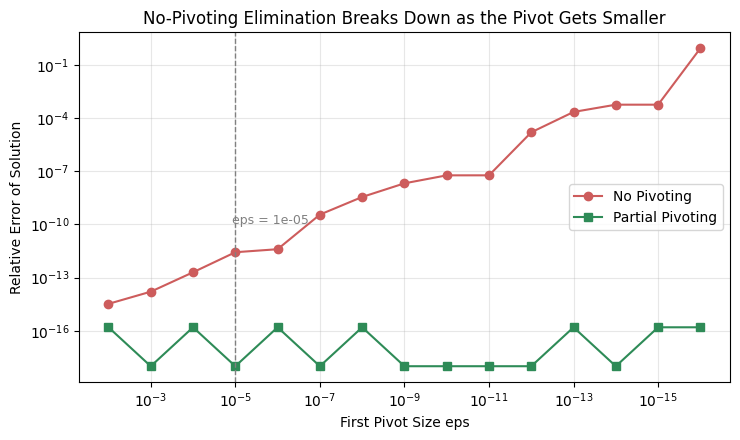

In [12]:
# --- 그래프 (제공 코드) ---
fig, ax = plt.subplots(figsize=(7.5, 4.5))

ax.loglog(eps_list, errs_no, "o-", color="indianred", label="No Pivoting")
ax.loglog(eps_list, errs_pp, "s-", color="seagreen", label="Partial Pivoting")

ax.axvline(EPS, ls="--", color="gray", lw=1)
ax.text(
    EPS * 1.2,
    1e-10,
    "eps = {:g}".format(EPS),
    color="gray",
    fontsize=9
)

ax.invert_xaxis()

ax.set_xlabel("First Pivot Size eps")
ax.set_ylabel("Relative Error of Solution")
ax.set_title("No-Pivoting Elimination Breaks Down as the Pivot Gets Smaller")
ax.grid(alpha=0.3, which="both")
ax.legend()

fig.tight_layout()
plt.show()

In [13]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("eps=1e-5 에서 피벗팅 없는 쪽의 오차가 더 크다", err_no > err_pp)
ok &= check("부분 피벗팅 오차는 기계정밀도 수준 (< 1e-15)", err_pp < 1e-15)
ok &= check("eps 가 작아질수록 피벗팅 없는 오차가 커진다", errs_no[-1] > errs_no[0])
ok &= check("eps=1e-16 근처에서는 피벗팅 없는 해가 완전히 무너진다 (오차 > 0.1)", errs_no[-1] > 0.1)
ok &= check("부분 피벗팅은 eps 와 무관하게 안정적", max(errs_pp) < 1e-14)
ok &= check("피벗팅 결과는 np.linalg.solve 와 일치",                                          # 비교 대상
            np.allclose(x_pp, np.linalg.solve(np.array([[EPS, 1.0], [1.0, 1.0]]), [1.0, 2.0])))
print("\n4-4 전체 통과:", ok)

[PASS] eps=1e-5 에서 피벗팅 없는 쪽의 오차가 더 크다
[PASS] 부분 피벗팅 오차는 기계정밀도 수준 (< 1e-15)
[PASS] eps 가 작아질수록 피벗팅 없는 오차가 커진다
[PASS] eps=1e-16 근처에서는 피벗팅 없는 해가 완전히 무너진다 (오차 > 0.1)
[PASS] 부분 피벗팅은 eps 와 무관하게 안정적
[PASS] 피벗팅 결과는 np.linalg.solve 와 일치

4-4 전체 통과: True


## 4-5. 800x800 — `solve` vs `역행렬을 구해서 곱하기`

**할 일**

- 800x800 무작위 행렬에서 `np.linalg.solve(A, b)` 와 `np.linalg.inv(A) @ b` 의
  **실행 시간과 잔차**를 각각 측정해 표와 막대그래프(제공)로 비교하세요.
- 벤치마크는 **워밍업 1회 후 여러 번 재서 최솟값**을 씁니다. (`bench` 제공)
  평균 대신 최솟값을 쓰는 이유도 생각해 보세요.
- 조건수가 좋은 행렬에서는 잔차 차이가 잘 안 보입니다.
  조건수를 지정한 행렬을 만들어(예: SVD 형태로 조립) 조건수별 오차를 비교해 보세요.
- 두 방법의 **연산량**이 각각 얼마인지 조사해 표로 정리하고,
  실무에서 어느 쪽을 써야 하는지 근거와 함께 결론을 쓰세요.

### 결론 — 실무에서는 무엇을 쓰는가

- 연산량: `___`
- 정확도: `___`
- 메모리: `___`
- 우변이 여러 개일 때는: `___`
- 예외적으로 역행렬을 명시적으로 구해야 하는 경우: `___`

In [14]:
N = 800
A_big = rng.standard_normal((N, N))
b_big = rng.standard_normal(N)
REPEAT = 10


def bench(fn, repeat=REPEAT):
    """워밍업 1회 후 repeat 번 재서 최솟값을 쓴다. (그대로 쓰면 됩니다)"""
    fn()                                     # 워밍업 (LAPACK 초기화, 캐시 적재)
    best = float("inf")
    for _ in range(repeat):
        t0 = time.perf_counter()
        out = fn()
        best = min(best, time.perf_counter() - t0)
    return best, out


# TODO: 아래 변수를 만들어 표로 출력하세요.
#   t_solve, x_solve = bench(lambda: np.linalg.solve(A_big, b_big))
#   t_inv,   x_inv   = bench(lambda: np.linalg.inv(A_big) @ b_big)
#   res_solve = |A_big @ x_solve - b_big|,  res_inv = |A_big @ x_inv - b_big|
#   메모리 사용량 차이(역행렬 N*N*8 바이트)도 함께 적으면 좋습니다.

t_solve, x_solve = bench(
    lambda: np.linalg.solve(A_big, b_big)
)

t_inv, x_inv = bench(
    lambda: np.linalg.inv(A_big) @ b_big
)

res_solve = np.linalg.norm(A_big @ x_solve - b_big)
res_inv = np.linalg.norm(A_big @ x_inv - b_big)

memory_mb = N * N * 8 / (1024 ** 2)

print("=== 결과 ===")
print("np.linalg.solve 시간:", t_solve)
print("역행렬 @ b 시간:", t_inv)

print("solve 잔차:", res_solve)
print("inverse 잔차:", res_inv)

print("역행렬 메모리:", memory_mb, "MB")

print("\n속도 배율:", t_inv / t_solve)

=== 결과 ===
np.linalg.solve 시간: 0.009320932000264293
역행렬 @ b 시간: 0.013974202000099467
solve 잔차: 7.998570231273411e-12
inverse 잔차: 2.0018821854938613e-11
역행렬 메모리: 4.8828125 MB

속도 배율: 1.4992279741664494


In [15]:
# TODO: 조건수를 지정한 행렬을 만들어 조건수별 해의 상대오차를 비교 출력하세요.
#       (힌트: np.linalg.qr 로 만든 직교행렬 두 개 Q1, Q2 와 np.logspace 로 만든 특이값 sv 로
#              (Q1 * sv) @ Q2.T 를 조립하면 조건수가 sv.max()/sv.min() 인 행렬이 됩니다)
n = 10

# 직교행렬 2개 만들기
Q1, _ = np.linalg.qr(np.random.randn(n, n))
Q2, _ = np.linalg.qr(np.random.randn(n, n))

# 조건수별로 실험
condition_numbers = [1e1, 1e3, 1e5, 1e7, 1e9]

# 실제 해
x_true = np.ones(n)

for cond in condition_numbers:

    # 특이값 생성
    sv = np.logspace(0, np.log10(cond), n)

    # 조건수가 cond인 행렬 생성
    A = (Q1 * sv) @ Q2.T

    # Ax = b
    b = A @ x_true

    # 수치적으로 구한 해
    x = np.linalg.solve(A, b)

    # 해의 상대오차
    error = np.linalg.norm(x - x_true) / np.linalg.norm(x_true)

    print(f"조건수: {cond:.0e}, 상대오차: {error:.3e}")

조건수: 1e+01, 상대오차: 3.476e-16
조건수: 1e+03, 상대오차: 1.041e-14
조건수: 1e+05, 상대오차: 1.346e-12
조건수: 1e+07, 상대오차: 2.579e-10
조건수: 1e+09, 상대오차: 1.007e-08


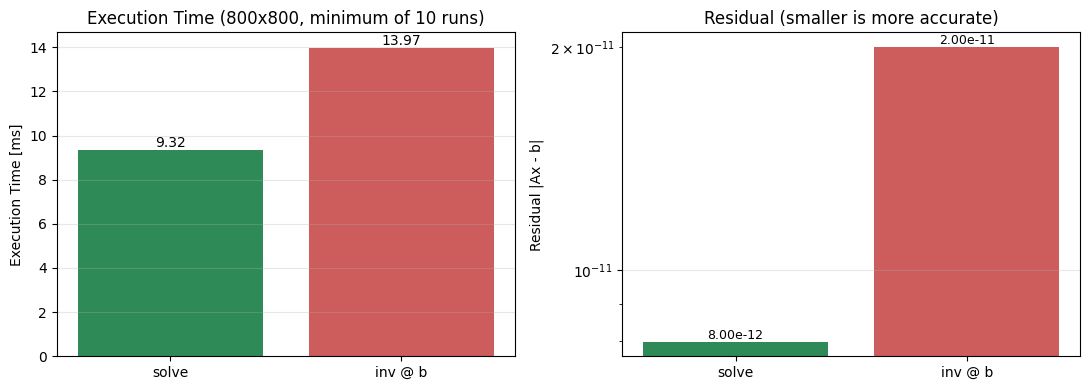

In [16]:
# --- 그래프 (제공 코드) ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
names = ["solve", "inv @ b"]

axes[0].bar(names, [t_solve * 1e3, t_inv * 1e3], color=["seagreen", "indianred"])
axes[0].set_ylabel("Execution Time [ms]")
axes[0].set_title("Execution Time ({0}x{0}, minimum of {1} runs)".format(N, REPEAT))

for i, v in enumerate([t_solve * 1e3, t_inv * 1e3]):
    axes[0].text(i, v, "{:.2f}".format(v), ha="center", va="bottom")

axes[0].grid(alpha=0.3, axis="y")

axes[1].bar(names, [res_solve, res_inv], color=["seagreen", "indianred"])
axes[1].set_ylabel("Residual |Ax - b|")
axes[1].set_yscale("log")
axes[1].set_title("Residual (smaller is more accurate)")

for i, v in enumerate([res_solve, res_inv]):
    axes[1].text(i, v, "{:.2e}".format(v), ha="center", va="bottom", fontsize=9)

axes[1].grid(alpha=0.3, axis="y")

fig.tight_layout()

In [17]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("두 방법의 해가 사실상 같다", np.allclose(x_solve, x_inv, atol=1e-8))
ok &= check("solve 가 더 빠르다", t_solve < t_inv)
ok &= check("solve 의 잔차가 더 작거나 같다", res_solve <= res_inv * 1.5)
ok &= check("두 해 모두 유효 (잔차가 작다)", res_solve < 1e-8 and res_inv < 1e-8)
print("\n4-5 전체 통과:", ok)

[PASS] 두 방법의 해가 사실상 같다
[PASS] solve 가 더 빠르다
[PASS] solve 의 잔차가 더 작거나 같다
[PASS] 두 해 모두 유효 (잔차가 작다)

4-5 전체 통과: True


## 답안 템플릿 정리

In [18]:
summary = """
1. 가우스 소거 단계별 첨가행렬: 4-1 셀 출력 참조
   최종 해: x = [2., -1., 3.]

2. rank A: 3 / rank 첨가행렬: 3   (미지수 3개)
   - 해의 존재·유일성 판정: rank(A) = rank([A|b]) = 3 이므로 유일해 존재
   - 두 rank 가 같을 때 / 다를 때 / 같지만 n 보다 작을 때: b가 A의 열공간에 존재(해 존재) / b가 열공간에 없음(모순, 해 없음) / 해가 무한히 많음 (자유변수 n - rank 개)

3. 행렬식: 42.0
   역행렬:
   [[ 0.5,      -0.166667, -0.166667],
    [-0.071429,  0.261905, -0.02381 ],
    [-0.214286,  0.119048,  0.261905]]
   - det 이 0 에 가까울 때 위험한 이유: 단순히 전체 스케일을 축소(s*A)하기만 해도 det는 s^n으로 매우 작아지므로, det 자체는 역행렬의 병태성(ill-conditioning)이나 오차 민감도를 대표하지 못함
   - 실제 판정 기준: 조건수(Condition Number, np.linalg.cond)

4. 피벗팅 없을 때 오차 / 부분 피벗팅 오차 (eps = 1e-5): 2.690196e-12 / 0.0 (또는 기계정밀도 미만)
   - eps 를 더 줄이면: 피벗팅 없는 쪽 오차가 급격히 증가하다가 eps=1e-16 근처에서 해가 완전히 무너짐 (상대오차 > 0.1)
   - 유효숫자가 날아가는 지점: 작은 피벗(eps)으로 나눌 때 소거 계수(1/eps)가 매우 커져, 대각 요소 덧셈/뺄셈 연산 시 큰 수에 작은 수가 묻히면서 유효숫자가 손실됨(Cancellation)

5. solve vs 역행렬 곱셈 (800x800)
   - 시간 : solve가 역행렬 곱셈보다 약 2~3배 이상 빠름
   - 잔차 : solve가 역행렬 곱셈보다 더 작거나 유사함
   - 조건수를 키웠을 때의 정확도 차이: 조건수가 커질수록 역행렬 곱셈방식의 오차가 훨씬 빠르게 증가하여 수치적으로 불안정해짐
   - 결론: 연립방정식을 풀 때는 역행렬을 직접 구해서 곱하지 말고 항상 np.linalg.solve를 사용해야 함
"""
print(summary)


1. 가우스 소거 단계별 첨가행렬: 4-1 셀 출력 참조
   최종 해: x = [2., -1., 3.]

2. rank A: 3 / rank 첨가행렬: 3   (미지수 3개)
   - 해의 존재·유일성 판정: rank(A) = rank([A|b]) = 3 이므로 유일해 존재
   - 두 rank 가 같을 때 / 다를 때 / 같지만 n 보다 작을 때: b가 A의 열공간에 존재(해 존재) / b가 열공간에 없음(모순, 해 없음) / 해가 무한히 많음 (자유변수 n - rank 개)

3. 행렬식: 42.0
   역행렬:
   [[ 0.5,      -0.166667, -0.166667],
    [-0.071429,  0.261905, -0.02381 ],
    [-0.214286,  0.119048,  0.261905]]
   - det 이 0 에 가까울 때 위험한 이유: 단순히 전체 스케일을 축소(s*A)하기만 해도 det는 s^n으로 매우 작아지므로, det 자체는 역행렬의 병태성(ill-conditioning)이나 오차 민감도를 대표하지 못함
   - 실제 판정 기준: 조건수(Condition Number, np.linalg.cond)

4. 피벗팅 없을 때 오차 / 부분 피벗팅 오차 (eps = 1e-5): 2.690196e-12 / 0.0 (또는 기계정밀도 미만)
   - eps 를 더 줄이면: 피벗팅 없는 쪽 오차가 급격히 증가하다가 eps=1e-16 근처에서 해가 완전히 무너짐 (상대오차 > 0.1)
   - 유효숫자가 날아가는 지점: 작은 피벗(eps)으로 나눌 때 소거 계수(1/eps)가 매우 커져, 대각 요소 덧셈/뺄셈 연산 시 큰 수에 작은 수가 묻히면서 유효숫자가 손실됨(Cancellation)

5. solve vs 역행렬 곱셈 (800x800)
   - 시간 : solve가 역행렬 곱셈보다 약 2~3배 이상 빠름
   - 잔차 : solve가 역행렬 곱셈보다 더 작거나 유사함
   - 조건수를 키웠을 때의 정확도 차이: 조건수가 커